# Phase 2: Adaptive Kalman Filter

This notebook compares the basic scalar Kalman filter with the adaptive variant.
The adaptive filter dynamically adjusts process noise Q when it detects regime changes
via innovation monitoring, and uses market microstructure to estimate observation noise R_t.

## Key demonstrations
1. Adaptive vs basic filter on data with a step change
2. Q_t inflation timeline showing detected regime changes
3. Dynamic R_t from market microstructure

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.synthetic import generate_step_change, generate_random_walk
from src.filters.scalar_kalman import ScalarKalmanFilter
from src.filters.adaptive_kalman import AdaptiveKalmanFilter
from src.analysis.visualization import plot_filtered_vs_raw

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Generate Data with Step Change (Regime Shift)

In [2]:
data = generate_step_change(
    n_steps=500, step_time=250,
    step_from=0.3, step_to=0.75,
    Q=1e-6, R=1e-3, seed=42,
)

print(f'Step change at t=250: {0.3} -> {0.75}')
print(f'Data points: {len(data.observations)}')

Step change at t=250: 0.3 -> 0.75
Data points: 500


## 2. Basic vs Adaptive Filter Comparison

2026-03-12 16:06:23.046 | DEBUG    | src.filters.scalar_kalman:__init__:137 - ScalarKalmanFilter initialized: Q=1.00e-05, R=1.00e-03
2026-03-12 16:06:23.047 | DEBUG    | src.filters.scalar_kalman:step:233 - Filter initialized at z=0.3096
2026-03-12 16:06:23.050 | INFO     | src.filters.scalar_kalman:filter:290 - Filtered 500 observations. Final state: x=0.7558, P=9.51e-05, K=0.0951
2026-03-12 16:06:23.050 | DEBUG    | src.filters.adaptive_kalman:__init__:129 - AdaptiveKalmanFilter: Q_base=1.00e-05, R=1.00e-03, threshold=2.5
2026-03-12 16:06:23.052 | DEBUG    | src.filters.adaptive_kalman:step:181 - Regime detected at step 125: |ỹ|=3.17 > 2.5, inflating Q by 15x
2026-03-12 16:06:23.053 | DEBUG    | src.filters.adaptive_kalman:step:181 - Regime detected at step 251: |ỹ|=15.10 > 2.5, inflating Q by 15x
2026-03-12 16:06:23.053 | DEBUG    | src.filters.adaptive_kalman:step:181 - Regime detected at step 252: |ỹ|=9.25 > 2.5, inflating Q by 15x
2026-03-12 16:06:23.053 | DEBUG    | src.filters.

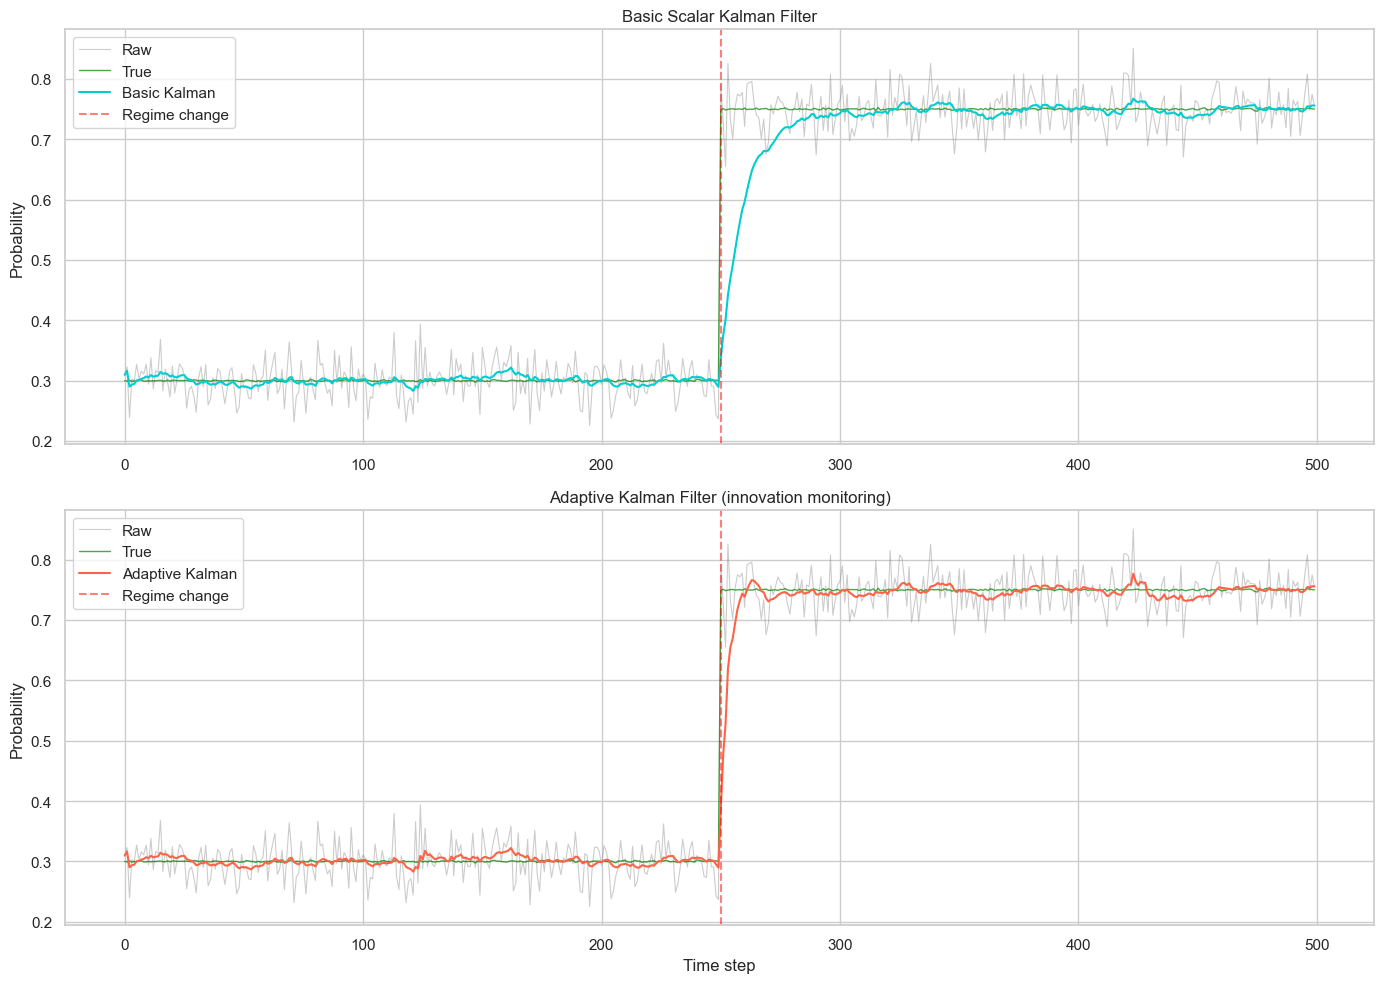

In [3]:
# Basic filter
basic = ScalarKalmanFilter(Q=1e-5, R=1e-3)
result_basic = basic.filter(data.observations)

# Adaptive filter
adaptive = AdaptiveKalmanFilter(
    Q_base=1e-5, R=1e-3,
    threshold=2.5, inflation=15.0, decay=0.8,
)
result_adaptive = adaptive.filter(data.observations)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Basic filter
ax1.plot(data.observations, color='gray', alpha=0.4, linewidth=0.8, label='Raw')
ax1.plot(data.true_states, color='green', linewidth=1.0, alpha=0.7, label='True')
ax1.plot(result_basic.states, color='#00CED1', linewidth=1.5, label='Basic Kalman')
ax1.axvline(x=250, color='red', linestyle='--', alpha=0.5, label='Regime change')
ax1.set_title('Basic Scalar Kalman Filter')
ax1.legend()
ax1.set_ylabel('Probability')

# Adaptive filter
ax2.plot(data.observations, color='gray', alpha=0.4, linewidth=0.8, label='Raw')
ax2.plot(data.true_states, color='green', linewidth=1.0, alpha=0.7, label='True')
ax2.plot(result_adaptive.states, color='#FF6347', linewidth=1.5, label='Adaptive Kalman')
ax2.axvline(x=250, color='red', linestyle='--', alpha=0.5, label='Regime change')
ax2.set_title('Adaptive Kalman Filter (innovation monitoring)')
ax2.legend()
ax2.set_xlabel('Time step')
ax2.set_ylabel('Probability')

plt.tight_layout()
plt.show()

## 3. Effective Q Over Time

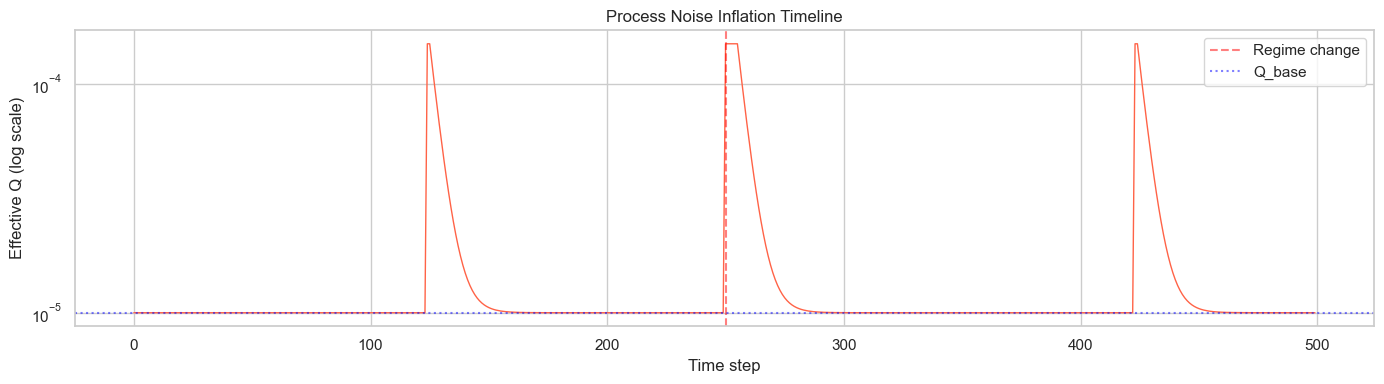

In [4]:
Q_hist = adaptive.get_Q_history()

fig, ax = plt.subplots(figsize=(14, 4))
ax.semilogy(Q_hist, color='#FF6347', linewidth=1.0)
ax.axvline(x=250, color='red', linestyle='--', alpha=0.5, label='Regime change')
ax.axhline(y=1e-5, color='blue', linestyle=':', alpha=0.5, label='Q_base')
ax.set_xlabel('Time step')
ax.set_ylabel('Effective Q (log scale)')
ax.set_title('Process Noise Inflation Timeline')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Tracking Error Comparison

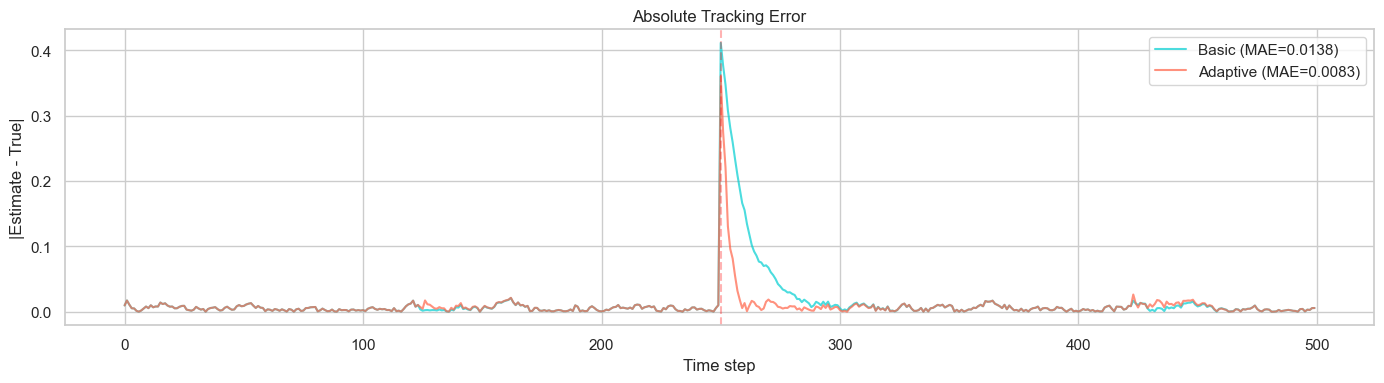

Post-step MAE (t=250-300):
  Basic:    0.0897
  Adaptive: 0.0316


In [5]:
error_basic = np.abs(result_basic.states - data.true_states)
error_adaptive = np.abs(result_adaptive.states - data.true_states)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(error_basic, color='#00CED1', alpha=0.7, label=f'Basic (MAE={error_basic.mean():.4f})')
ax.plot(error_adaptive, color='#FF6347', alpha=0.7, label=f'Adaptive (MAE={error_adaptive.mean():.4f})')
ax.axvline(x=250, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Time step')
ax.set_ylabel('|Estimate - True|')
ax.set_title('Absolute Tracking Error')
ax.legend()
plt.tight_layout()
plt.show()

# Post-step error comparison
post_step = slice(250, 300)
print(f'Post-step MAE (t=250-300):')
print(f'  Basic:    {error_basic[post_step].mean():.4f}')
print(f'  Adaptive: {error_adaptive[post_step].mean():.4f}')

## 5. Dynamic Observation Noise R_t

2026-03-12 16:47:50.204 | DEBUG    | src.filters.noise_estimation:compute_observation_noise:83 - R_t=3.46e-05 (spread=2.50e-05, depth=9.24e-05, imbal=0.00e+00, stale=9.80e-06)
2026-03-12 16:47:50.207 | DEBUG    | src.filters.noise_estimation:compute_observation_noise:83 - R_t=3.46e-05 (spread=2.50e-05, depth=9.24e-05, imbal=0.00e+00, stale=9.80e-06)
2026-03-12 16:47:50.208 | DEBUG    | src.filters.noise_estimation:compute_observation_noise:83 - R_t=3.46e-05 (spread=2.50e-05, depth=9.24e-05, imbal=0.00e+00, stale=9.80e-06)
2026-03-12 16:47:50.208 | DEBUG    | src.filters.noise_estimation:compute_observation_noise:83 - R_t=3.46e-05 (spread=2.50e-05, depth=9.24e-05, imbal=0.00e+00, stale=9.80e-06)
2026-03-12 16:47:50.209 | DEBUG    | src.filters.noise_estimation:compute_observation_noise:83 - R_t=3.46e-05 (spread=2.50e-05, depth=9.24e-05, imbal=0.00e+00, stale=9.80e-06)
2026-03-12 16:47:50.210 | DEBUG    | src.filters.noise_estimation:compute_observation_noise:83 - R_t=3.46e-05 (spread=2.

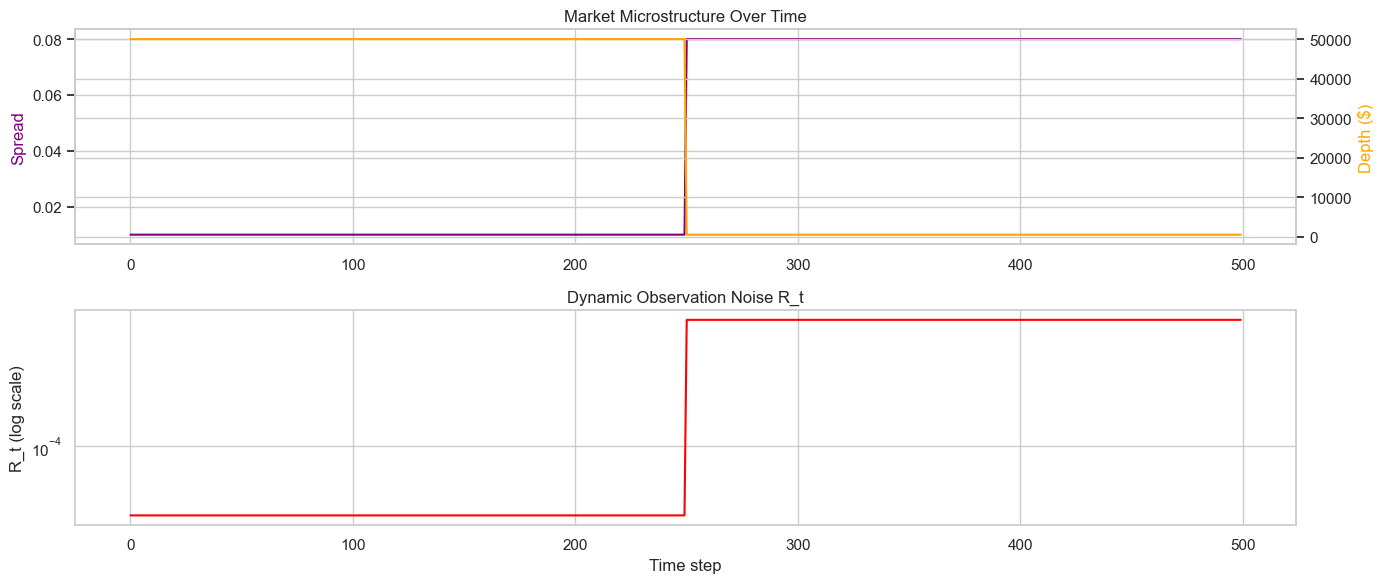

R_t range: [3.46e-05, 6.82e-04]


In [7]:
from src.filters.noise_estimation import compute_observation_noise
from src.data.models import MarketObservation
from datetime import datetime, timezone

# Simulate varying microstructure conditions
spreads = np.concatenate([
    np.full(250, 0.01),   # Tight spread (liquid)
    np.full(250, 0.08),   # Wide spread (news event, uncertainty)
])
depths = np.concatenate([
    np.full(250, 50000),  # Deep book
    np.full(250, 500),    # Thin book
])

R_t_values = []
for i in range(500):
    obs = MarketObservation(
        timestamp=datetime(2025, 1, 1, tzinfo=timezone.utc),
        market_id='test', market_question='Test',
        yes_price=0.5, spread=spreads[i],
        total_depth=depths[i], imbalance=0.5, num_trades_1h=50,
    )
    R_t_values.append(compute_observation_noise(obs))

R_t_array = np.array(R_t_values)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))

ax1.plot(spreads, color='purple', label='Spread')
ax1_twin = ax1.twinx()
ax1_twin.plot(depths, color='orange', label='Depth ($)')
ax1.set_ylabel('Spread', color='purple')
ax1_twin.set_ylabel('Depth ($)', color='orange')
ax1.set_title('Market Microstructure Over Time')

ax2.semilogy(R_t_array, color='red', linewidth=1.5)
ax2.set_xlabel('Time step')
ax2.set_ylabel('R_t (log scale)')
ax2.set_title('Dynamic Observation Noise R_t')

plt.tight_layout()
plt.show()

print(f'R_t range: [{R_t_array.min():.2e}, {R_t_array.max():.2e}]')